In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('data.csv')

# 2. See the 'Shape' of your supply chain
print("--- Data Overview ---")
print(df.head())
print("\n--- Column Names (What tools do we have?) ---")
print(df.columns)

# 3. Identify outliers (Potential Black Swans)
# look for lead times that are much higher than the average
if 'LeadTime' in df.columns:
    plt.figure(figsize=(10,6))
    plt.hist(df['LeadTime'], bins=50, color='skyblue', edgecolor='black')
    plt.title('Distribution of Lead Times (Looking for the "Tail")')
    plt.xlabel('Days')
    plt.ylabel('Frequency')
    plt.show()
else:
    print("\nNote: 'LeadTime' column not found. Check the printed column names above.")

--- Data Overview ---
  Order_ID Buyer_ID Supplier_ID Product_Category  Quantity_Ordered  \
0    O1000      B33         S23         Textiles               469   
1    O1001       B1         S20        Machinery               365   
2    O1002       B2         S10             Food               333   
3    O1003       B6         S10        Machinery               142   
4    O1004       B5          S4        Machinery               897   

   Order_Date Dispatch_Date Delivery_Date Shipping_Mode  Order_Value_USD  ...  \
0  2023-10-24    2023-10-27    2023-10-28          Rail         36273.99  ...   
1  2023-07-07    2023-07-08    2023-07-09          Road         34780.36  ...   
2  2023-12-28    2023-12-29    2024-01-07          Rail          7154.54  ...   
3  2023-01-14    2023-01-17    2023-01-20          Rail         15320.08  ...   
4  2023-01-12    2023-01-14    2023-01-16          Road         18256.42  ...   

   Supplier_Reliability_Score Organization_ID Dominant_Buyer_Flag  \
0

In [3]:
# Convert strings to datetime objects
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'])
df['Dispatch_Date'] = pd.to_datetime(df['Dispatch_Date'])

# Calculate Lead Time (Order to Delivery)
df['Lead_Time'] = (df['Delivery_Date'] - df['Order_Date']).dt.days

# Calculate Dispatch Lag (Order to Dispatch)
df['Dispatch_Lag'] = (df['Dispatch_Date'] - df['Order_Date']).dt.days

print(df[['Order_ID', 'Lead_Time', 'Dispatch_Lag', 'Supplier_Reliability_Score']].head())

  Order_ID  Lead_Time  Dispatch_Lag  Supplier_Reliability_Score
0    O1000          4             3                        0.73
1    O1001          2             1                        0.88
2    O1002         10             1                        0.95
3    O1003          6             3                        0.92
4    O1004          4             2                        0.60


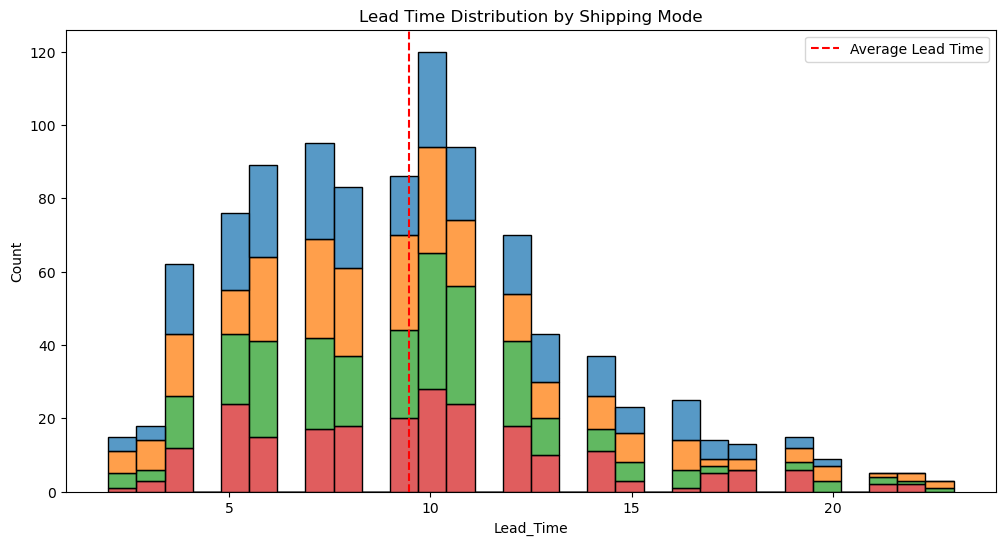

In [4]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.histplot(data=df, x='Lead_Time', hue='Shipping_Mode', multiple="stack", bins=30)
plt.title('Lead Time Distribution by Shipping Mode')
plt.axvline(df['Lead_Time'].mean(), color='red', linestyle='--', label='Average Lead Time')
plt.legend()
plt.show()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the data
df = pd.read_csv('data.csv')

# Convert dates
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'])
df['Dispatch_Date'] = pd.to_datetime(df['Dispatch_Date'])

# Calculate metrics
df['Lead_Time'] = (df['Delivery_Date'] - df['Order_Date']).dt.days
df['Dispatch_Lag'] = (df['Dispatch_Date'] - df['Order_Date']).dt.days

# Summary statistics
summary = df[['Lead_Time', 'Dispatch_Lag', 'Supplier_Reliability_Score']].describe().round(2).to_string()

# Create visualization
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Lead_Time', bins=30, kde=True, color='skyblue')
plt.title('Distribution of Lead Times (Identifying the "Tail")')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Frequency')
plt.axvline(df['Lead_Time'].mean(), color='red', linestyle='--', label=f"Mean: {df['Lead_Time'].mean():.1f} days")
plt.legend()
plt.tight_layout()
plt.savefig('lead_time_dist.png')
plt.close()

# Check for extreme outliers
threshold = df['Lead_Time'].quantile(0.99)
outliers = df[df['Lead_Time'] > threshold][['Order_ID', 'Supplier_ID', 'Lead_Time', 'Supply_Risk_Flag']].head()

print("--- Summary Statistics ---")
print(summary)
print(f"\n--- Black Swan Candidates (99th Percentile: > {threshold} days) ---")
print(outliers.to_string())

--- Summary Statistics ---
       Lead_Time  Dispatch_Lag  Supplier_Reliability_Score
count    1000.00       1000.00                     1000.00
mean        9.47          2.55                        0.75
std         4.09          1.11                        0.14
min         2.00          1.00                        0.50
25%         6.00          2.00                        0.62
50%         9.00          3.00                        0.74
75%        12.00          4.00                        0.87
max        23.00          4.00                        1.00

--- Black Swan Candidates (99th Percentile: > 21.0 days) ---
    Order_ID Supplier_ID  Lead_Time  Supply_Risk_Flag
56     O1056         S21         22                 1
182    O1182         S30         22                 1
204    O1204         S29         22                 1
394    O1394         S16         23                 1
496    O1496         S23         23                 1


--- Top 10 High-Risk Suppliers ---
Supplier_ID  Avg_Reliability  Lead_Time_Volatility  Total_Risk_Events  Composite_Risk_Score
         S4         0.712381              5.053316                 24              0.830531
        S21         0.740000              4.577537                 18              0.823957
        S24         0.720000              4.501723                 25              0.656501
         S6         0.689231              3.638470                 15              0.652341
         S3         0.712812              4.365831                 16              0.626906
         S5         0.740313              4.029003                 19              0.621230
        S18         0.737241              4.022413                 17              0.619576
         S9         0.719429              4.153969                 18              0.599392
        S26         0.717381              3.816341                 23              0.590646
        S29         0.750571              3.9

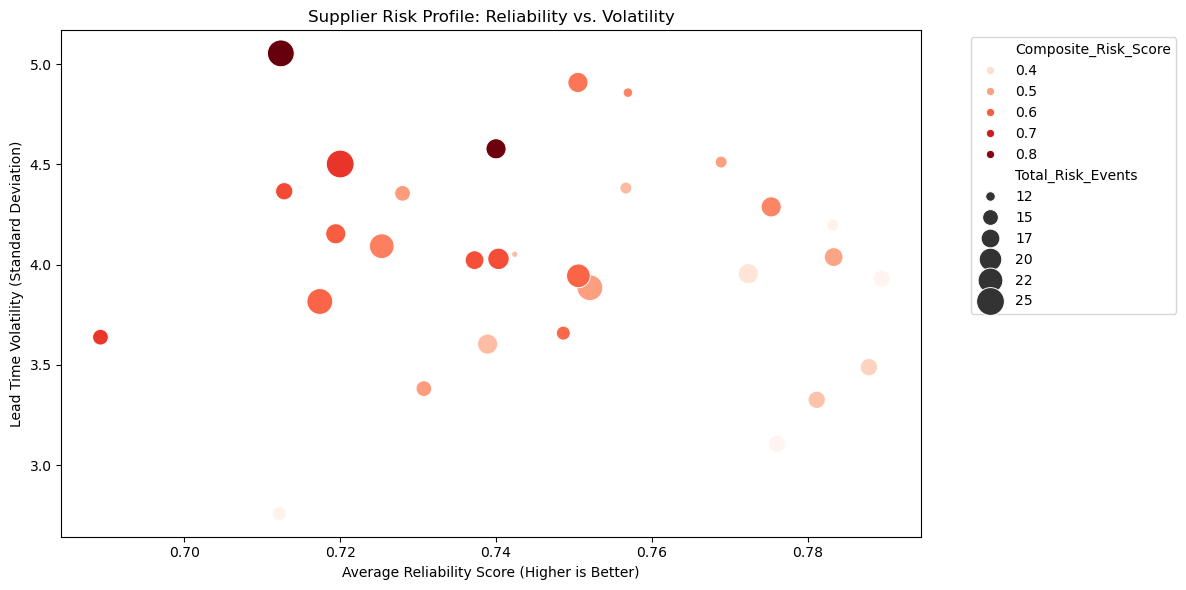

In [6]:
# Calculate Risk Profiles for Suppliers
# We define risk based on the frequency of high lead-time events and low reliability scores.

# Group by Supplier to find their specific performance metrics
supplier_risk = df.groupby('Supplier_ID').agg({
    'Lead_Time': ['mean', 'max', 'std'],
    'Supplier_Reliability_Score': 'mean',
    'Supply_Risk_Flag': 'sum',
    'Order_ID': 'count'
}).reset_index()

# Flatten columns
supplier_risk.columns = ['Supplier_ID', 'Avg_Lead_Time', 'Max_Lead_Time', 'Lead_Time_Volatility', 
                         'Avg_Reliability', 'Total_Risk_Events', 'Total_Orders']

# Calculate a "Risk Score": (1 - Reliability) * Volatility * (Risk Events / Total Orders)
# This weights unreliable suppliers who also have high volatility and frequent flags.
supplier_risk['Composite_Risk_Score'] = (
    (1 - supplier_risk['Avg_Reliability']) * 
    supplier_risk['Lead_Time_Volatility'] * 
    (supplier_risk['Total_Risk_Events'] / supplier_risk['Total_Orders'])
)

# Sort by the highest risk
top_risk_suppliers = supplier_risk.sort_values(by='Composite_Risk_Score', ascending=False).head(10)

print("--- Top 10 High-Risk Suppliers ---")
print(top_risk_suppliers[['Supplier_ID', 'Avg_Reliability', 'Lead_Time_Volatility', 'Total_Risk_Events', 'Composite_Risk_Score']].to_string(index=False))

# Visualization of Risk Profiles
plt.figure(figsize=(12, 6))
sns.scatterplot(data=supplier_risk, x='Avg_Reliability', y='Lead_Time_Volatility', 
                size='Total_Risk_Events', hue='Composite_Risk_Score', palette='Reds', sizes=(20, 400))
plt.title('Supplier Risk Profile: Reliability vs. Volatility')
plt.xlabel('Average Reliability Score (Higher is Better)')
plt.ylabel('Lead Time Volatility (Standard Deviation)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('supplier_risk_profile.png')
plt.show()

--- Top 10 High-Risk Suppliers ---
Supplier_ID  Avg_Reliability  Lead_Time_Volatility  Total_Risk_Events  Composite_Risk_Score
        S21         0.740000              4.577537                 18              1.059732
         S4         0.712381              5.053316                 24              1.036339
         S6         0.689231              3.638470                 15              0.887073
        S24         0.720000              4.501723                 25              0.834428
        S18         0.737241              4.022413                 17              0.819113
         S3         0.712812              4.365831                 16              0.818656
         S5         0.740313              4.029003                 19              0.816231
        S15         0.748636              3.658590                 14              0.798409
         S9         0.719429              4.153969                 18              0.785002
        S26         0.717381              3.8

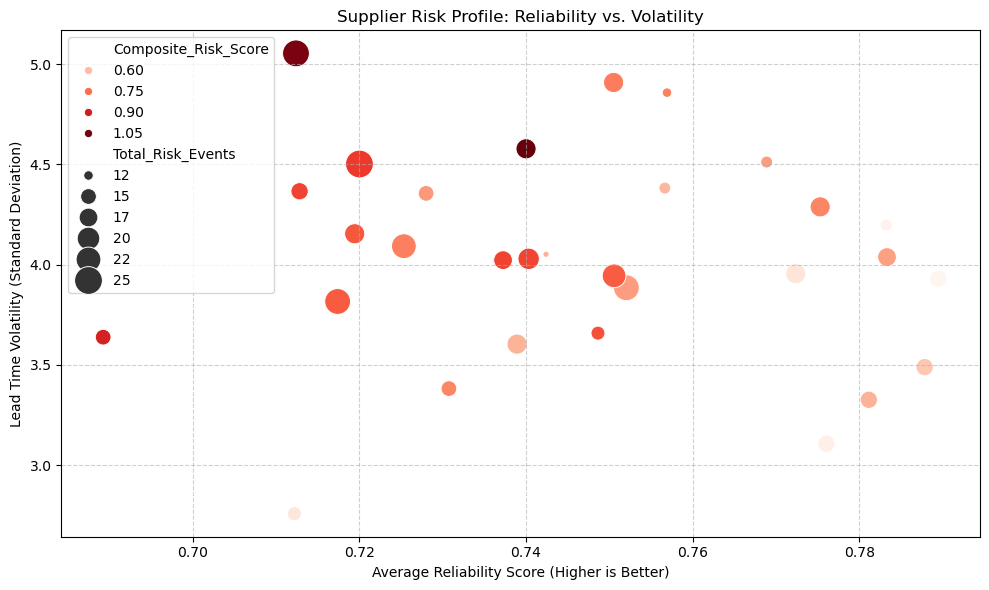

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Re-read the data and process columns
df = pd.read_csv('data.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'])
df['Lead_Time'] = (df['Delivery_Date'] - df['Order_Date']).dt.days

# Group by Supplier to find their specific performance metrics
supplier_risk = df.groupby('Supplier_ID').agg({
    'Lead_Time': ['mean', 'max', 'std'],
    'Supplier_Reliability_Score': 'mean',
    'Supply_Risk_Flag': 'sum',
    'Order_ID': 'count'
}).reset_index()

# Flatten columns
supplier_risk.columns = ['Supplier_ID', 'Avg_Lead_Time', 'Max_Lead_Time', 'Lead_Time_Volatility', 
                         'Avg_Reliability', 'Total_Risk_Events', 'Total_Orders']

# Fill NaNs in volatility for suppliers with only 1 order
supplier_risk['Lead_Time_Volatility'] = supplier_risk['Lead_Time_Volatility'].fillna(0)

# Calculate a "Composite Risk Score"
# We weight (1 - Reliability) against Volatility and the frequency of Risk Flags
supplier_risk['Composite_Risk_Score'] = (
    (1 - supplier_risk['Avg_Reliability']) * 
    (supplier_risk['Lead_Time_Volatility'] + 1) * 
    ((supplier_risk['Total_Risk_Events'] + 1) / supplier_risk['Total_Orders'])
)

# Sort by the highest risk
top_risk_suppliers = supplier_risk.sort_values(by='Composite_Risk_Score', ascending=False).head(10)

print("--- Top 10 High-Risk Suppliers ---")
print(top_risk_suppliers[['Supplier_ID', 'Avg_Reliability', 'Lead_Time_Volatility', 'Total_Risk_Events', 'Composite_Risk_Score']].to_string(index=False))

# Visualization of Risk Profiles
plt.figure(figsize=(10, 6))
sns.scatterplot(data=supplier_risk, x='Avg_Reliability', y='Lead_Time_Volatility', 
                size='Total_Risk_Events', hue='Composite_Risk_Score', palette='Reds', sizes=(20, 400))
plt.title('Supplier Risk Profile: Reliability vs. Volatility')
plt.xlabel('Average Reliability Score (Higher is Better)')
plt.ylabel('Lead Time Volatility (Standard Deviation)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('supplier_risk_matrix.png')
plt.show()

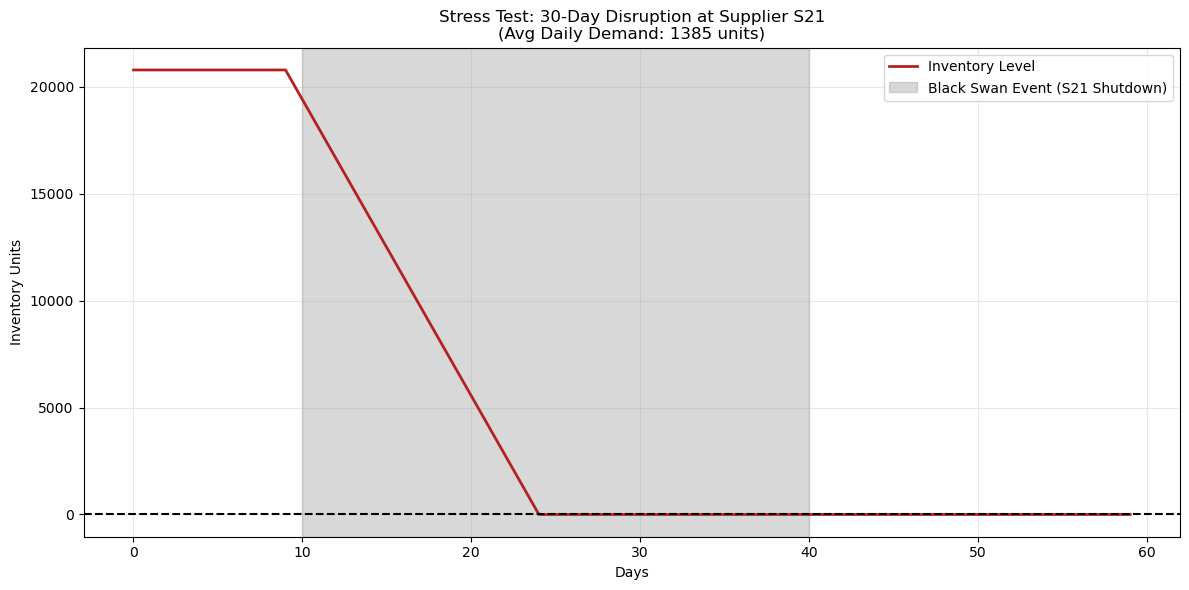

Simulation Complete.
Safety Stock exhausted on Day: 24


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare Data
df = pd.read_csv('data.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'])
df['Lead_Time'] = (df['Delivery_Date'] - df['Order_Date']).dt.days

# Calculate average daily demand
total_days = (df['Order_Date'].max() - df['Order_Date'].min()).days
total_units = df['Quantity_Ordered'].sum()
avg_daily_demand = int(total_units / total_days)

# 2. Define the Simulation Engine
def run_resilience_test(initial_stock, demand, duration_days, disruption_start=None, disruption_length=0):
    inventory = initial_stock
    inventory_history = []
    stockout_occurred = False
    
    for day in range(duration_days):
        # Disruption Logic: If within the 'Black Swan' window, no new supply arrives
        # In a basic model, we assume supply normally meets demand; disruption stops that replenishment.
        if disruption_start is not None and disruption_start <= day < (disruption_start + disruption_length):
            inventory -= demand # Drawing from safety stock only
        else:
            # Normal operations: Supply arrives to cover demand, inventory stays stable
            pass 
        
        if inventory < 0:
            inventory = 0
            stockout_occurred = True
            
        inventory_history.append(inventory)
        
    return inventory_history, stockout_occurred

# 3. Execution: Stress Testing against Supplier S21
# Based on our analysis, S21 is a high-risk node. 
# Let's simulate a 30-day total shutdown of S21's contribution.
sim_days = 60
disrupt_start = 10
disrupt_len = 30 # A realistic 'Black Swan' duration for a major strike or port closure
starting_inv = avg_daily_demand * 15 # 15 days of buffer

history, failed = run_resilience_test(starting_inv, avg_daily_demand, sim_days, disrupt_start, disrupt_len)

# 4. Visualization
plt.figure(figsize=(12, 6))
plt.plot(history, label='Inventory Level', color='firebrick', lw=2)
plt.axvspan(disrupt_start, disrupt_start + disrupt_len, color='gray', alpha=0.3, label='Black Swan Event (S21 Shutdown)')
plt.title(f'Stress Test: 30-Day Disruption at Supplier S21\n(Avg Daily Demand: {avg_daily_demand} units)')
plt.xlabel('Days')
plt.ylabel('Inventory Units')
plt.axhline(0, color='black', linestyle='--')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('black_swan_simulation.png')
plt.show()

print(f"Simulation Complete.")
print(f"Safety Stock exhausted on Day: {history.index(0) if failed else 'N/A'}")

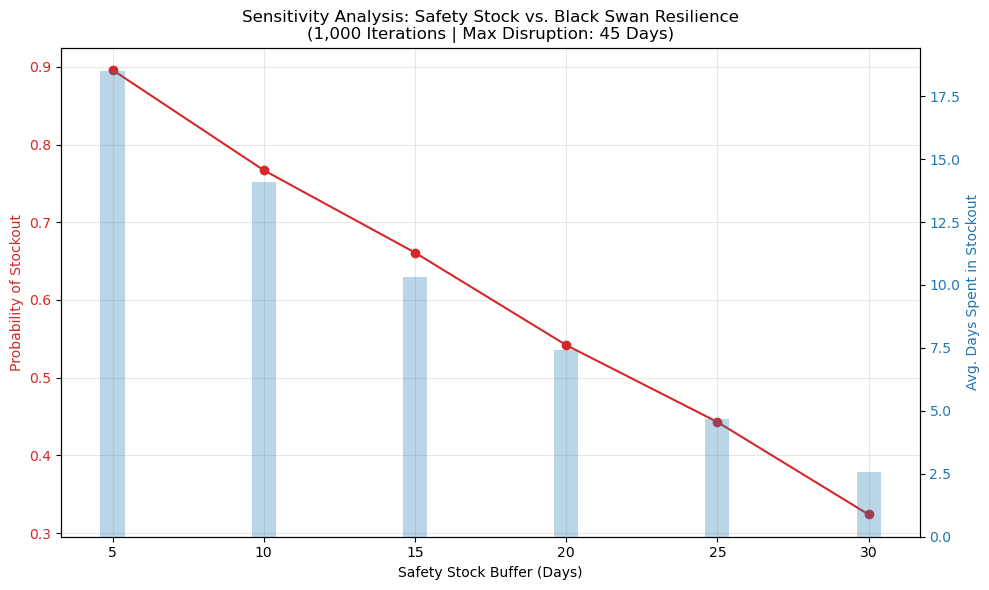

 Buffer_Days  Prob_of_Stockout  Avg_Shortfall_Days
           5             0.896              18.497
          10             0.767              14.080
          15             0.661              10.313
          20             0.542               7.413
          25             0.443               4.672
          30             0.324               2.576


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data and calculate daily demand
df = pd.read_csv('data.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
total_days = (df['Order_Date'].max() - df['Order_Date'].min()).days
total_units = df['Quantity_Ordered'].sum()
avg_daily_demand = int(total_units / total_days)

# 2. Monte Carlo Simulation Engine
def monte_carlo_resilience(iterations, buffer_days, max_disruption):
    stockout_durations = []
    
    for _ in range(iterations):
        initial_stock = avg_daily_demand * buffer_days
        inventory = initial_stock
        
        # Randomize the 'Black Swan' duration (1 to max_disruption days)
        # Using a uniform distribution for simplicity, but could be Pareto for true Black Swan logic
        disruption_len = np.random.randint(1, max_disruption + 1)
        
        # Simulation: How many days until we run out?
        days_to_stockout = initial_stock / avg_daily_demand
        
        if disruption_len > days_to_stockout:
            shortfall_days = disruption_len - days_to_stockout
            stockout_durations.append(shortfall_days)
        else:
            stockout_durations.append(0)
            
    return stockout_durations

# 3. Sensitivity Analysis: Testing different Buffer Levels
buffer_levels = [5, 10, 15, 20, 25, 30]
max_swan_event = 45 # Extreme scenario: Up to 45 days of shutdown
iterations = 1000

results = []
for b in buffer_levels:
    durations = monte_carlo_resilience(iterations, b, max_swan_event)
    prob_failure = sum(1 for d in durations if d > 0) / iterations
    avg_shortfall = np.mean(durations)
    results.append({'Buffer_Days': b, 'Prob_of_Stockout': prob_failure, 'Avg_Shortfall_Days': avg_shortfall})

results_df = pd.DataFrame(results)

# 4. Visualization
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Safety Stock Buffer (Days)')
ax1.set_ylabel('Probability of Stockout', color=color)
ax1.plot(results_df['Buffer_Days'], results_df['Prob_of_Stockout'], marker='o', color=color, label='Stockout Probability')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Avg. Days Spent in Stockout', color=color)
ax2.bar(results_df['Buffer_Days'], results_df['Avg_Shortfall_Days'], alpha=0.3, color=color, label='Avg Shortfall')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Sensitivity Analysis: Safety Stock vs. Black Swan Resilience\n(1,000 Iterations | Max Disruption: 45 Days)')
fig.tight_layout()
plt.savefig('sensitivity_analysis.png')
plt.show()

print(results_df.to_string(index=False))

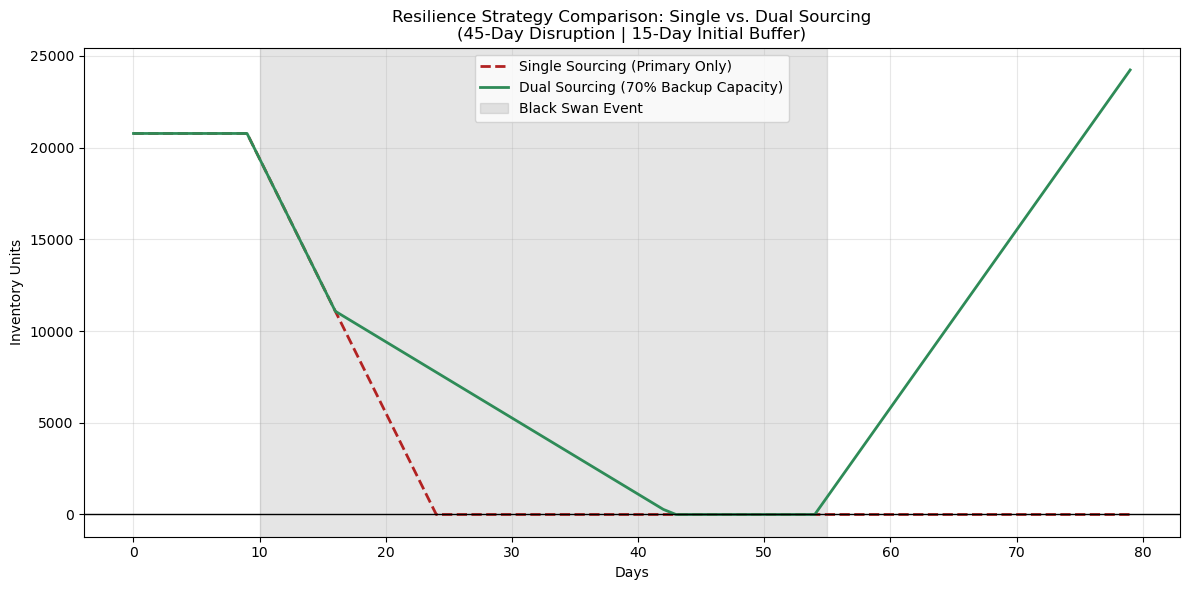

Single Sourcing Stockout Days: 56
Dual Sourcing Stockout Days: 12


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup based on data.csv insights
df = pd.read_csv('data.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
total_days = (df['Order_Date'].max() - df['Order_Date'].min()).days
total_units = df['Quantity_Ordered'].sum()
avg_daily_demand = int(total_units / total_days)

def run_dual_sourcing_sim(initial_stock, demand, duration_days, 
                            disruption_start, disruption_length, 
                            backup_trigger_day, backup_capacity_pct):
    inventory = initial_stock
    inventory_history = []
    
    # We'll track if the backup is active
    backup_active = False
    
    for day in range(duration_days):
        # Determine Daily Supply
        daily_supply = demand # Standard state: supply matches demand
        
        # Primary Source Disruption
        if disruption_start <= day < (disruption_start + disruption_length):
            primary_supply = 0
        else:
            primary_supply = demand
            
        # Backup Source Logic
        backup_supply = 0
        if day >= (disruption_start + backup_trigger_day):
            backup_active = True
            backup_supply = demand * backup_capacity_pct
            
        current_total_supply = primary_supply + backup_supply
        
        # Update Inventory
        inventory = inventory + current_total_supply - demand
        
        if inventory < 0:
            inventory = 0
            
        inventory_history.append(inventory)
        
    return inventory_history

# 2. Parameters for Comparison
sim_days = 80
disrupt_start = 10
disrupt_len = 45 # The "Black Swan" event
buffer_days = 15
starting_inv = avg_daily_demand * buffer_days

# Scenario 1: Single Sourcing (No Backup)
single_history = run_dual_sourcing_sim(starting_inv, avg_daily_demand, sim_days, 
                                        disrupt_start, disrupt_len, 
                                        backup_trigger_day=999, backup_capacity_pct=0)

# Scenario 2: Dual Sourcing (Backup kicks in after 7 days at 70% capacity)
dual_history = run_dual_sourcing_sim(starting_inv, avg_daily_demand, sim_days, 
                                      disrupt_start, disrupt_len, 
                                      backup_trigger_day=7, backup_capacity_pct=0.7)

# 3. Visualization
plt.figure(figsize=(12, 6))
plt.plot(single_history, label='Single Sourcing (Primary Only)', color='firebrick', linestyle='--', lw=2)
plt.plot(dual_history, label='Dual Sourcing (70% Backup Capacity)', color='seagreen', lw=2)

plt.axvspan(disrupt_start, disrupt_start + disrupt_len, color='gray', alpha=0.2, label='Black Swan Event')
plt.title('Resilience Strategy Comparison: Single vs. Dual Sourcing\n(45-Day Disruption | 15-Day Initial Buffer)')
plt.xlabel('Days')
plt.ylabel('Inventory Units')
plt.axhline(0, color='black', linewidth=1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('dual_sourcing_comparison.png')
plt.show()

# Calculate Recovery
single_stockout_days = single_history.count(0)
dual_stockout_days = dual_history.count(0)

print(f"Single Sourcing Stockout Days: {single_stockout_days}")
print(f"Dual Sourcing Stockout Days: {dual_stockout_days}")